# Scoperta dell'Object-Centric Petri Net

## Obiettivo

Scoprire un Object-Centric Petri Net (OCPN) a partire dal dataset
Order Management in formato OCEL 2.0.

A differenza di una Petri net tradizionale basata su un unico case
identifier, una OCPN mantiene distinti i diversi tipi di oggetto
coinvolti nello stesso processo.

## 1. Caricamento del dataset e configurazione

Il dataset viene caricato tramite la funzione centralizzata
`load_ocel2_sqlite`. I percorsi degli artefatti sono ricavati dalla
configurazione del progetto, così il notebook può essere eseguito sia
dalla root sia dalla cartella `notebooks` senza generare output in
posizioni errate.

In [1]:
import pm4py

from ocpm_partial_order.config import (
    FIGURES_DIR,
    MAIN_DATASET_DB,
    REPORTS_DIR,
)
from ocpm_partial_order.discovery.ocpn_discovery import (
    discover_ocpn,
)
from ocpm_partial_order.io.ocel_loader import (
    load_ocel2_sqlite,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

ocel = load_ocel2_sqlite(MAIN_DATASET_DB)




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




## 2. Scoperta del modello

La funzione `discover_ocpn` applica l'algoritmo di discovery
object-centric fornito da PM4Py. Il risultato è un dizionario che
contiene il modello e le strutture statistiche utilizzate per
costruirlo.

In [2]:
ocpn = discover_ocpn(ocel)

print("Tipo risultato:", type(ocpn))
print("Chiavi principali:")
print(ocpn.keys())

Tipo risultato: <class 'pm4py.objects.ocpn.obj.OCPetriNet'>
Chiavi principali:
KeysView(OCPN :
object_types: [ employees, items, orders, packages, products ]
places: [ employees_p_10[employees], employees_p_11[employees], employees_p_13[employees], employees_p_14[employees], employees_p_15[employees], employees_p_16[employees], employees_p_17[employees], employees_p_18[employees], employees_p_21[employees], employees_p_22[employees], employees_p_24[employees], employees_p_25[employees], employees_p_26[employees], employees_p_3[employees], employees_p_4[employees], employees_p_5[employees], employees_p_6[employees], employees_sink[employees], employees_source[employees], items_p_5[items], items_p_6[items], items_p_7[items], items_sink[items], items_source[items], orders_p_3[orders], orders_p_4[orders], orders_p_5[orders], orders_p_6[orders], orders_p_7[orders], orders_sink[orders], orders_source[orders], packages_p_3[packages], packages_p_4[packages], packages_p_5[packages], packages_p_

## 3. Visualizzazione interattiva

La cella seguente apre la rappresentazione grafica della OCPN.
Richiede Graphviz installato e disponibile nel `PATH` di sistema.

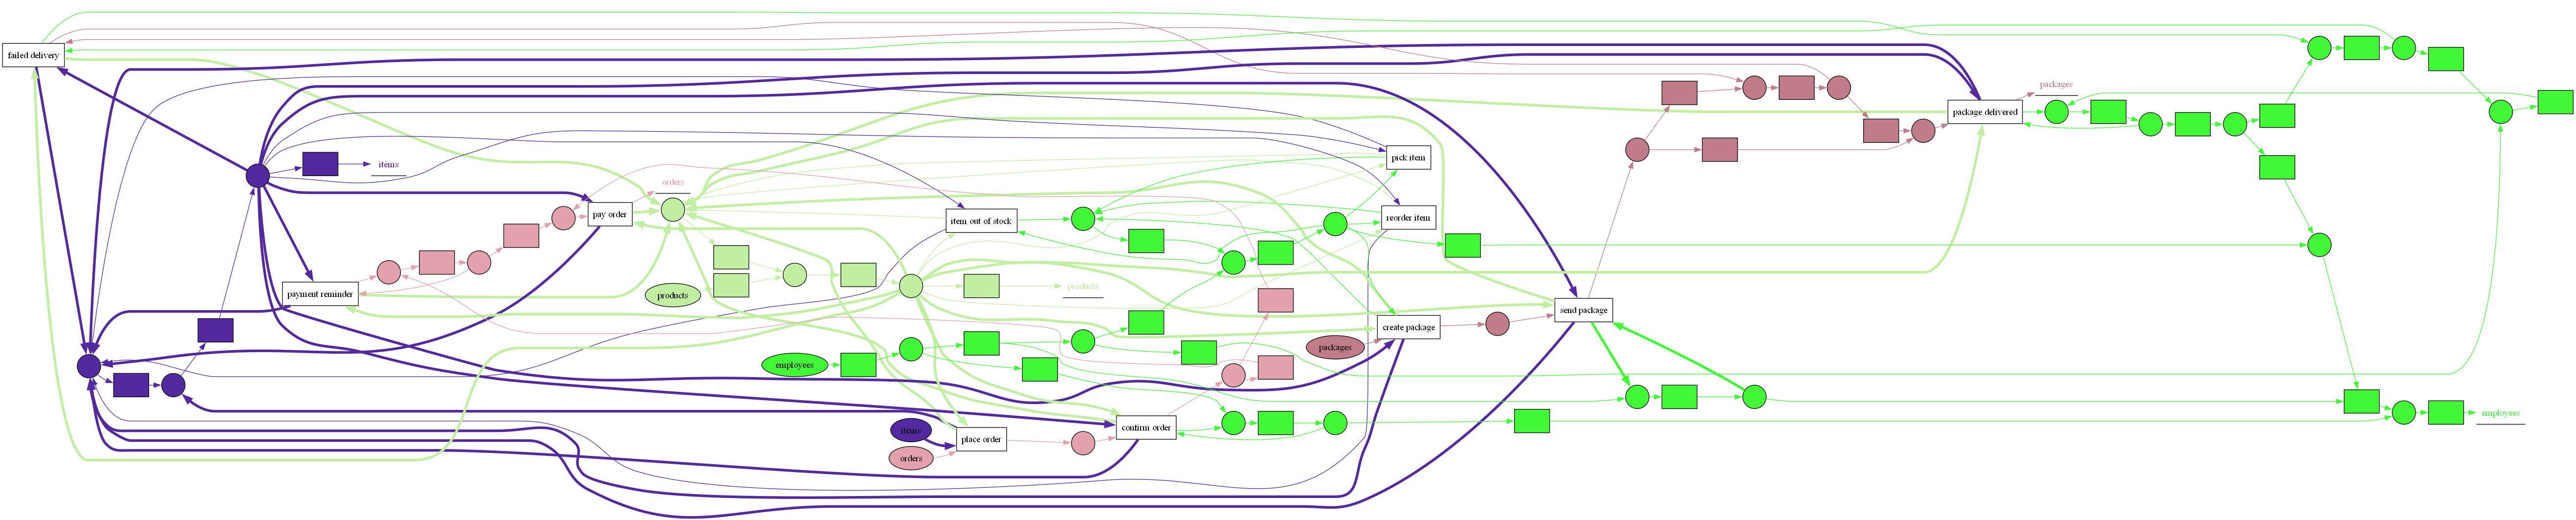

In [3]:
pm4py.view_ocpn(ocpn)

## 4. Esportazione della figura

La visualizzazione viene salvata in `outputs/figures`. L'immagine è
un artefatto rigenerabile e non viene versionata da Git.

In [4]:
ocpn_output_path = (
    FIGURES_DIR / "order_management_ocpn.png"
)

pm4py.save_vis_ocpn(
    ocpn,
    str(ocpn_output_path),
)

print("Modello salvato in:", ocpn_output_path)

Modello salvato in: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\outputs\figures\order_management_ocpn.png


## 5. Ispezione della struttura restituita

L'ispezione permette di verificare quali componenti siano state
prodotte dalla discovery senza assumere che sia già stato effettuato
il conformance checking.

In [5]:
for key, value in ocpn.items():
    print("=" * 70)
    print("CHIAVE:", key)
    print("TIPO:", type(value))

    if isinstance(value, dict):
        print("SOTTOCHIAVI:", list(value.keys())[:20])
    elif isinstance(value, (list, set, tuple)):
        print("DIMENSIONE:", len(value))
        print("PRIMI ELEMENTI:", list(value)[:5])
    else:
        print("VALORE:", value)

CHIAVE: activities
TIPO: <class 'set'>
DIMENSIONE: 11
PRIMI ELEMENTI: ['failed delivery', 'payment reminder', 'item out of stock', 'reorder item', 'create package']
CHIAVE: object_types
TIPO: <class 'set'>
DIMENSIONE: 5
PRIMI ELEMENTI: ['items', 'products', 'packages', 'orders', 'employees']
CHIAVE: edges
TIPO: <class 'dict'>
SOTTOCHIAVI: ['event_couples', 'unique_objects', 'total_objects']
CHIAVE: activities_indep
TIPO: <class 'dict'>
SOTTOCHIAVI: ['events', 'unique_objects', 'total_objects']
CHIAVE: activities_ot
TIPO: <class 'dict'>
SOTTOCHIAVI: ['events', 'unique_objects', 'total_objects']
CHIAVE: start_activities
TIPO: <class 'dict'>
SOTTOCHIAVI: ['events', 'unique_objects', 'total_objects']
CHIAVE: end_activities
TIPO: <class 'dict'>
SOTTOCHIAVI: ['events', 'unique_objects', 'total_objects']
CHIAVE: edges_performance
TIPO: <class 'dict'>
SOTTOCHIAVI: ['event_couples', 'total_objects']
CHIAVE: petri_nets
TIPO: <class 'dict'>
SOTTOCHIAVI: ['items', 'products', 'packages', 'orders',

## 6. Esportazione del report strutturale

La struttura principale viene salvata in `outputs/reports`. Anche
questo file è un artefatto generato automaticamente e viene escluso
dal repository.

In [6]:
summary_path = (
    REPORTS_DIR / "order_management_ocpn_structure.txt"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    for key, value in ocpn.items():
        file.write(f"KEY: {key}\n")
        file.write(f"TYPE: {type(value)}\n")

        if isinstance(value, dict):
            file.write(
                f"SUBKEYS: {list(value.keys())}\n"
            )
        elif isinstance(value, (list, set, tuple)):
            file.write(f"SIZE: {len(value)}\n")
        else:
            file.write(f"VALUE: {value}\n")

        file.write("\n")

print("Report salvato in:", summary_path)


Report salvato in: C:\Users\nicol\ocpm-partial-order\ocpm-partial-order\outputs\reports\order_management_ocpn_structure.txt


## Conclusioni

La discovery preliminare produce una OCPN relativa a 11 attività e
5 tipi di oggetto: `orders`, `items`, `packages`, `products` ed
`employees`.

Il risultato comprende una Petri net per ciascun tipo di oggetto,
oltre alle informazioni su archi, attività iniziali e finali,
molteplicità e prestazioni.

Questa analisi completa la scoperta e l'ispezione strutturale del
modello. Non dimostra ancora che una specifica process execution sia
fitting e non calcola una fitness pari a 1. La verifica di conformità
dovrà essere affrontata successivamente.